# S1 · 誠實的評估 —— 那個 0.756 到底是什麼

第一本 notebook 得到 AUROC ≈ 0.76，通關標準都達成了。

這本 notebook 問四個問題，而且**每一個的答案都對 VAE 不利**：

1. 一個**不看模型**的像素統計能做到多少？
2. ELBO 是在偵測病灶，還是在偵測「這張圖多難壓縮」？
3. 把下界收緊（IWAE）會讓偵測變好嗎？
4. β 與 latent 容量這兩個「該有影響」的旋鈕，影響有多大？

> 計劃書 §8.3 說「沒有對照的結果，說服力接近零」。
> 這本 notebook 是那句話的完整展開。

In [1]:
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # 必須在 import torch 前
import sys
sys.path.insert(0, "../src")

import numpy as np
import torch
import matplotlib.pyplot as plt

import data as D, vae as V, train as T, experiments as X, evaluate as E, plots as P

DATA_DIR = "../../data/A_medical"
dev = V.device()
print("device:", dev, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

device: cuda | NVIDIA GeForce RTX 5070 Ti


In [2]:
d = D.load(DATA_DIR)
model, info = T.train(d["train_normal"], d["val_normal"], latent_dim=16,
                      beta=1.0, epochs=300, seed=0)
sc_n = X.score_all(model, d["test_normal"], dev, iwae_K=20, seed=0)
sc_a = X.score_all(model, d["test_anomaly"], dev, iwae_K=20, seed=0)
table = X.auroc_table(sc_n, sc_a, n_boot=2000, seed=0)
print(f"VAE 的 −ELBO AUROC = {table['neg_elbo']['auroc']:.4f}")

VAE 的 −ELBO AUROC = 0.7555


## 1 · 對照基準：完全不看模型能做到多少

A3 專案的教訓在這裡重演一次。六個 trivial 統計量，每個都**不碰模型**：

| 統計量 | 直覺 |
|---|---|
| 像素熵 | 影像內容有多豐富 |
| 梯度能量 | 邊緣/紋理有多強 |
| L2 範數、平均強度、標準差 | 最粗糙的亮度統計 |
| **PNG 位元數** | 通用壓縮器眼中的複雜度 |

每個都試兩個方向並取較好的那個（等於讓 baseline 偷看標籤選方向）。
這對 baseline 是**有利**的設定 —— 刻意如此，因為我們要的是
「一個懶惰的方法最好能做到多少」的上界。低估它會讓模型看起來比實際更強。

In [3]:
triv = X.trivial_baselines(d["test_normal"], d["test_anomaly"], D, n_boot=2000, seed=0)
vae_auroc = table["neg_elbo"]["auroc"]
print(f"{'統計量':<20s} {'AUROC':>7s}  {'95% CI':>16s}  方向  對上 VAE")
for k, v in sorted(triv["scores"].items(), key=lambda kv: -kv[1]["auroc"]):
    flag = "  ← 打敗 VAE" if v["auroc"] > vae_auroc else ""
    print(f"{k:<20s} {v['auroc']:7.4f}  [{v['lo95']:.3f}, {v['hi95']:.3f}]  "
          f"{'反向' if v['flipped'] else '正向'}{flag}")
print(f"\n{'VAE (−ELBO)':<20s} {vae_auroc:7.4f}")

統計量                    AUROC            95% CI  方向  對上 VAE
gradient_energy       0.9147  [0.892, 0.936]  反向  ← 打敗 VAE
png_bits              0.8743  [0.846, 0.901]  反向  ← 打敗 VAE
pixel_entropy         0.8468  [0.813, 0.878]  反向  ← 打敗 VAE
std_intensity         0.8261  [0.791, 0.859]  反向  ← 打敗 VAE
mean_intensity        0.5750  [0.529, 0.622]  正向
l2_norm               0.5313  [0.486, 0.579]  正向

VAE (−ELBO)           0.7555


**四個 trivial 統計量打敗了 VAE，最好的一個高出 16 個百分點。**

而且**方向是「反向」的** —— 異常影像的梯度能量**較低**。
這正是第一本 notebook 肉眼看到的：肺炎片更糊、更平坦。

那個觀察當時看起來是模型的助力，現在變成了問題：
如果一個 `np.diff` 兩行就能算出來的量比整個 VAE 好，
那「VAE 學到了肺部的正常結構」這個說法就必須大幅打折。

⚠️ 注意這**不代表 trivial 統計量是更好的臨床工具**。它抓的是
「這張片子模糊」，而模糊的原因可以是肺炎，也可以是病人動了、曝光不足、
機器不同。它在這個資料集上有效，是因為 MedMNIST 的降採樣把
病理特徵壓成了低頻的明暗差異。換一批資料很可能立刻失效 ——
但那正是**必須報告它**的理由：它揭露了資料集本身的捷徑。

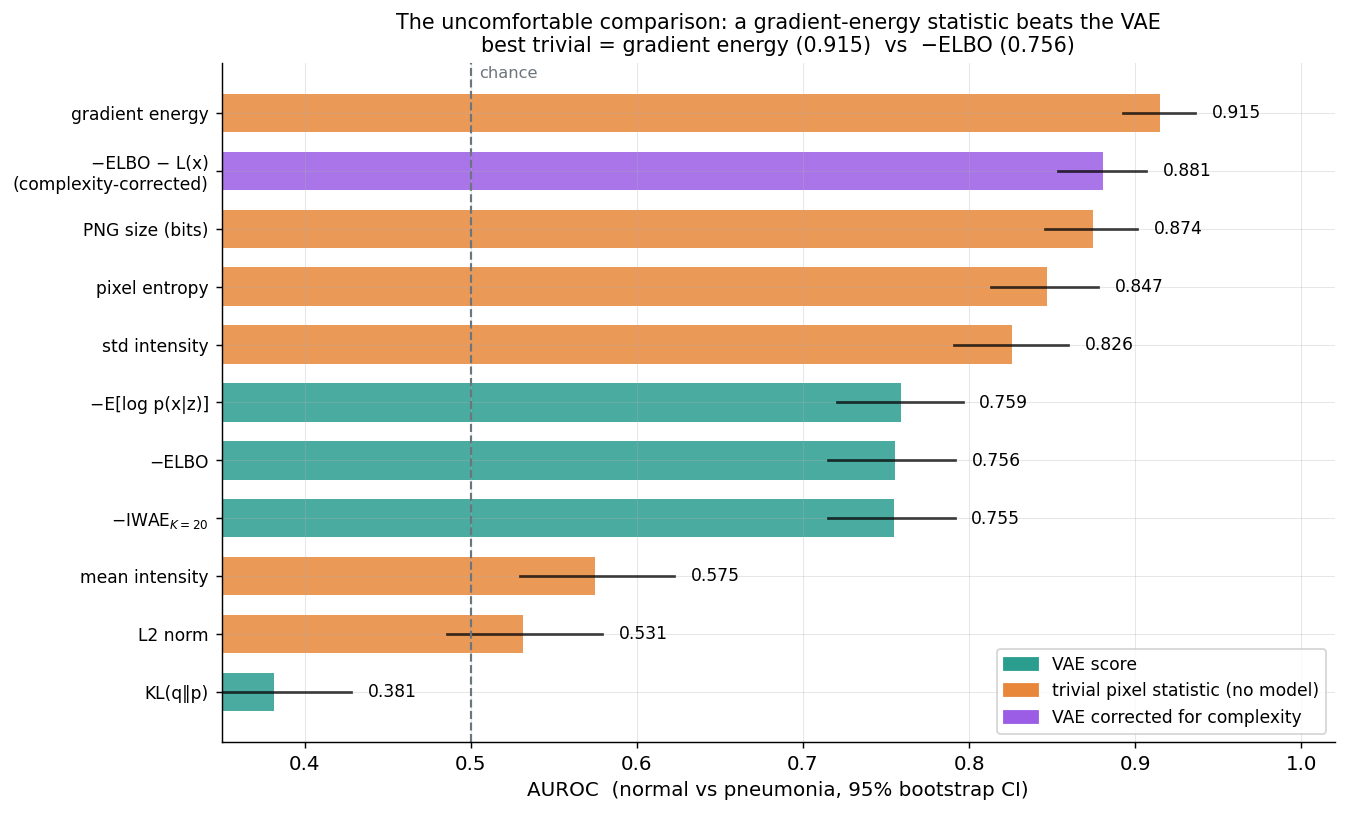

In [4]:
P.trivial_comparison(table, triv, X.complexity_corrected(sc_n, sc_a, triv, n_boot=2000),
                     "../figures/04_trivial_baseline.png")
from IPython.display import Image; Image("../figures/04_trivial_baseline.png")

## 2 · ELBO 在測量什麼？

上面的結果指向一個具體假設：**ELBO 大部分是在測量影像複雜度**。

這是深度生成模型的已知病（Nalisnick et al. 2019；Serrà et al. 2020）：
$\log p(x)$ 被影像的低階複雜度支配，簡單的圖得高分。
用 PNG 壓縮後的位元數當「無模型的複雜度代理」，三個角度檢驗：

1. **相關**：ELBO 與 PNG 位元數的 Spearman ρ
2. **分層 AUROC**：把樣本按複雜度分箱、**箱內**算 AUROC 再加權平均 ——
   箱內兩類的複雜度相當，剩下的判別力就不可能來自複雜度
3. **校正分數**：$S = -\mathrm{ELBO} - L(x)$，把複雜度成分直接扣掉

In [5]:
comp = X.complexity_analysis(sc_n, sc_a, triv, n_bins=8, n_boot=1000, seed=0)
sp = comp["spearman_elbo_vs_bits"]
print("Spearman(ELBO, PNG 位元數)")
print(f"  只用 normal   {sp['normal_only']:+.3f}")
print(f"  只用 anomaly  {sp['anomaly_only']:+.3f}")
print(f"  合併          {sp['pooled']:+.3f}")
print(f"\nPNG 位元數平均：normal {comp['bits_mean']['normal']:.0f}, "
      f"anomaly {comp['bits_mean']['anomaly']:.0f}")

Spearman(ELBO, PNG 位元數)
  只用 normal   +0.143
  只用 anomaly  +0.336
  合併          +0.447

PNG 位元數平均：normal 5265, anomaly 4824


In [6]:
floor = comp["stratified"]["png_bits_control"]["auroc"]
print(f"{'分數':>20s}  {'原始':>7s}  {'控制複雜度後':>12s}  {'95% CI':>16s}")
for k in X.SCORE_KEYS:
    st = comp["stratified"][k]
    print(f"{P.SCORE_LAB[k]:>20s}  {comp['raw_auroc'][k]:7.4f}  {st['auroc']:12.4f}  "
          f"[{st['lo95']:.3f}, {st['hi95']:.3f}]")
print(f"\n殘餘底線（複雜度對自己分層）= {floor:.4f}")
print(f"→ −ELBO 的淨貢獻 = {comp['stratified']['neg_elbo']['auroc'] - floor:+.4f}")

                  分數       原始        控制複雜度後            95% CI
               −ELBO   0.7555        0.6664  [0.603, 0.722]
      −E[log p(x|z)]   0.7591        0.6761  [0.615, 0.731]
             KL(q‖p)   0.3814        0.3679  [0.307, 0.426]
      −IWAE$_{K=20}$   0.7547        0.6665  [0.603, 0.723]

殘餘底線（複雜度對自己分層）= 0.5420
→ −ELBO 的淨貢獻 = +0.1244


**這裡有個方法論細節必須講清楚。**

分層之後，複雜度**對自己**分層應該掉到 0.5 —— 實際上掉到 0.542，不是 0.5。
原因是箱內仍有殘餘的複雜度變異（PNG 位元數是連續的，8 個箱切不乾淨）。

我沒有把這個殘餘當瑕疵藏起來，而是把它當作**對照底線**：
模型的分層 AUROC 要跟 0.542 比，不是跟 0.5 比。

而「切幾個箱」是個任意選擇，結論不該取決於它 —— 所以掃一遍：

In [7]:
print(f"{'箱數':>5s}  {'−ELBO':>8s}  {'殘餘底線':>9s}  {'淨貢獻':>8s}")
for r in comp["bin_sensitivity"]:
    print(f"{r['n_bins']:5d}  {r['neg_elbo']:8.4f}  {r['floor']:9.4f}  {r['net']:+8.4f}")

   箱數     −ELBO       殘餘底線       淨貢獻
    3    0.6838     0.6723   +0.0114
    5    0.6730     0.5874   +0.0856
    8    0.6664     0.5420   +0.1244
   10    0.6719     0.5695   +0.1024
   15    0.6714     0.5654   +0.1060
   20    0.6637     0.5621   +0.1015
   30    0.6779     0.5545   +0.1234


箱數從 5 到 30，淨貢獻穩定在 +0.09 ~ +0.12。
（k=3 例外：箱太寬，箱內殘餘複雜度太多，底線被高估。）

**結論**：VAE 確實學到了複雜度以外的東西，但那部分只有約 **0.10 AUROC**，
而原始的 0.756 裡有超過一半來自「這張圖多難壓縮」。

### 2.3 那就把複雜度扣掉

$S = -\mathrm{ELBO} - L(x)$，其中 $L(x)$ 是 PNG 的位元數（換算成 nats）。

直覺：$-\mathrm{ELBO}$ 大約是「用我的模型編碼這張圖要幾個 nat」。
如果一張圖對**任何**編碼器都很貴，那它的 $-\mathrm{ELBO}$ 大就不代表異常。
相減後剩下的是「我的模型比通用壓縮器差多少」。

In [8]:
corr = X.complexity_corrected(sc_n, sc_a, triv, n_boot=2000, seed=0)
for k, v in corr.items():
    pd_ = v["paired_delta"]
    print(f"{P.SCORE_LAB[k]:>20s}  {v['raw']['auroc']:.4f} → {v['corrected']['auroc']:.4f}"
          f"   Δ = {pd_['delta']:+.4f} [{pd_['lo95']:+.4f}, {pd_['hi95']:+.4f}]"
          f"   勝率 {pd_['win_rate']:.0%}")

               −ELBO  0.7555 → 0.8808   Δ = +0.1253 [+0.0843, +0.1691]   勝率 100%
      −IWAE$_{K=20}$  0.7547 → 0.8807   Δ = +0.1260 [+0.0848, +0.1693]   勝率 100%


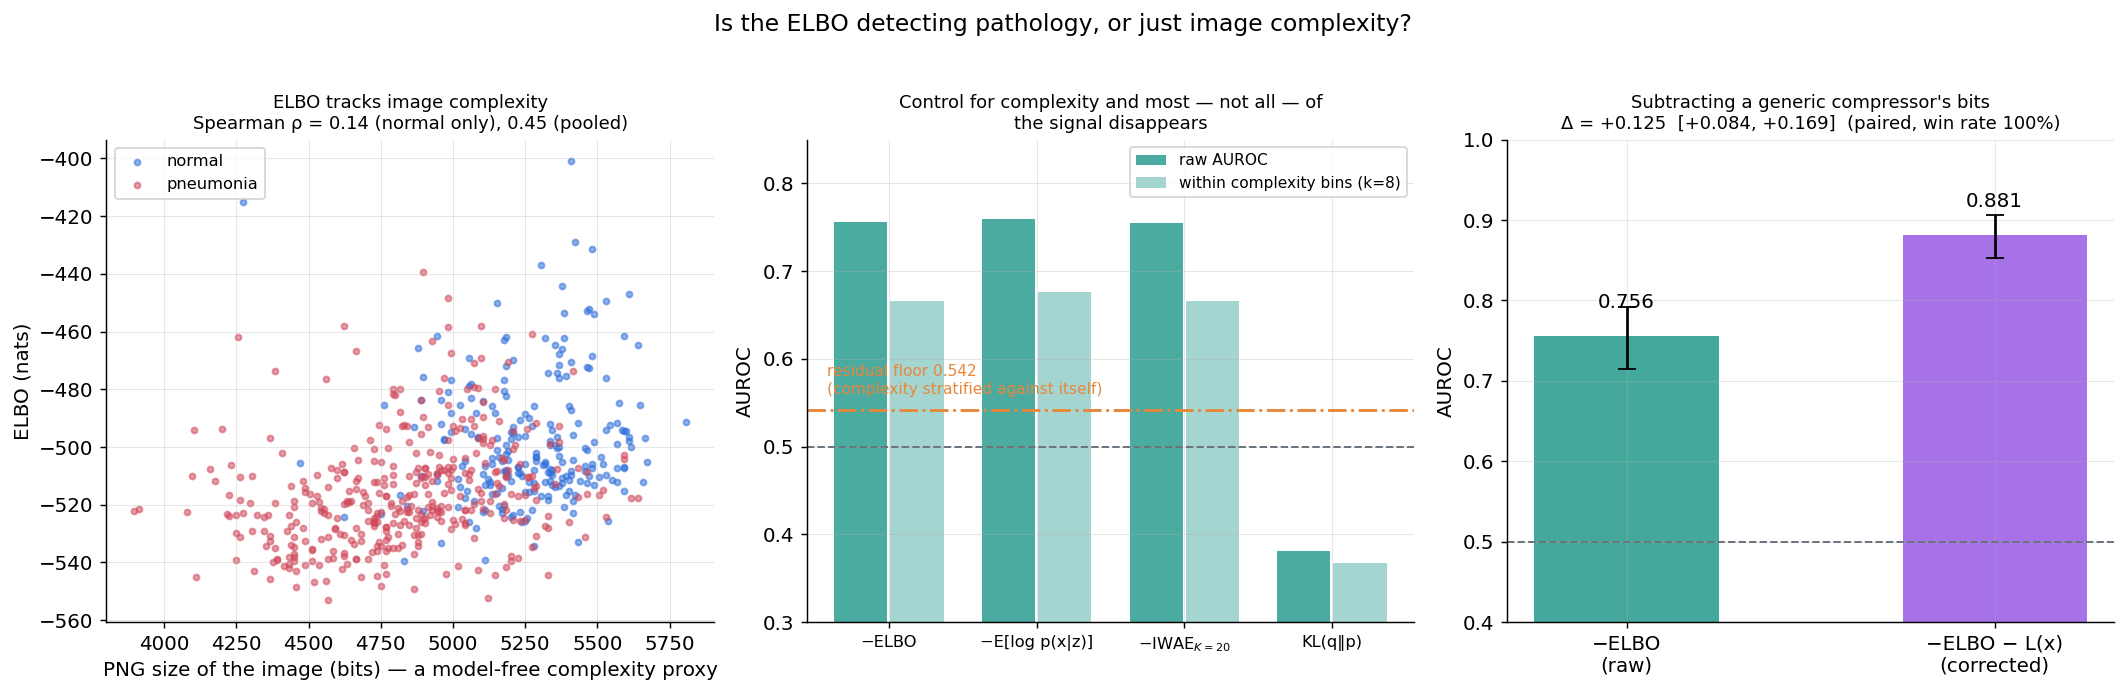

In [9]:
P.complexity_confound(sc_n, sc_a, triv, comp, corr, "../figures/05_complexity_confound.png")
Image("../figures/05_complexity_confound.png")

**+0.125 AUROC，配對 bootstrap 區間不含 0，勝率 100%。**

一個兩行的後處理，比任何超參數調整都有效（下一節會看到超參數幾乎沒用）。

但要誠實：校正後的 0.881 仍然**輸給** gradient energy 的 0.915。
扣掉複雜度讓 VAE 從「明顯較差」變成「接近但仍略差」。

---

## 3 · 三個旋鈕，以及一個噪聲底線

在比較任何設定之前，先問：**同一個設定重跑幾次，AUROC 會差多少？**

A3 的教訓：兩次「相同」執行的準確率差了 1.6 個百分點。
如果掃描的效應小於這個散佈，那個「趨勢」就是噪聲。

In [10]:
stab = X.seed_stability(d["train_normal"], d["val_normal"], d["test_normal"],
                        d["test_anomaly"], dev, seeds=(0,1,2,3,4), epochs=300,
                        latent_dim=16, n_boot=500)
print(f"\nAUROC = {stab['mean']:.4f} ± {stab['sd']:.4f}   "
      f"(範圍 {stab['min']:.4f} – {stab['max']:.4f})")

  seed=0 AUROC(elbo)=0.7555 active=14


  seed=1 AUROC(elbo)=0.7581 active=10


  seed=2 AUROC(elbo)=0.7574 active=11


  seed=3 AUROC(elbo)=0.7545 active=11


  seed=4 AUROC(elbo)=0.7612 active=11



AUROC = 0.7573 ± 0.0026   (範圍 0.7545 – 0.7612)


### 3.1 IWAE：收緊下界會幫助偵測嗎？

$$L_K = \mathbb{E}\left[\log \frac{1}{K}\sum_k w_k\right],\qquad w_k = \frac{p(x|z_k)p(z_k)}{q(z_k|x)}$$

性質：$L_1 = \mathrm{ELBO} \le L_K \le L_{K+1} \le \log p(x)$。K 就是「下界鬆緊」的旋鈕。

**為什麼這不是自明的**：ELBO 的鬆弛量是 $\mathrm{KL}(q\|p(z|x))$，
它本身帶有「這筆資料的後驗好不好近似」的資訊 —— 而那對異常偵測可能有用。
收緊下界會移除這個訊號。所以 K↑ 讓偵測**變差**是完全可能的。

In [11]:
iwae = X.iwae_sweep(model, d["test_normal"], d["test_anomaly"], dev,
                    K_list=(1,5,20,50,100), seed=0, n_boot=1000)
print(f"{'K':>5s}  {'AUROC':>7s}  {'95% CI':>16s}  {'L_K − ELBO (nats)':>18s}")
for r in iwae["rows"]:
    print(f"{r['K']:5d}  {r['auroc']:7.4f}  [{r['lo95']:.3f}, {r['hi95']:.3f}]  "
          f"{r['gap_to_elbo_normal']:18.3f}")
rng_ = max(r['auroc'] for r in iwae['rows']) - min(r['auroc'] for r in iwae['rows'])
print(f"\nAUROC 全距 {rng_:.4f} = {rng_/stab['sd']:.1f} 個 seed 標準差")

    K    AUROC            95% CI   L_K − ELBO (nats)
    1   0.7546  [0.714, 0.789]               0.070
    5   0.7548  [0.714, 0.789]               0.437
   20   0.7547  [0.714, 0.789]               0.538
   50   0.7551  [0.714, 0.789]               0.582
  100   0.7548  [0.714, 0.789]               0.615

AUROC 全距 0.0005 = 0.2 個 seed 標準差


**下界確實收緊了（+0.6 nats），AUROC 紋絲不動。**

答案是：兩者都不是。收緊量 0.6 nats 相對於 ELBO 本身的 −496 量級是
**0.1%** —— 近似品質這個成分在總分裡佔比太小，既不是訊號也不是噪聲來源。

這是個有用的負面結果：**在這個任務上，K=1 就夠了**，IWAE 的 100 倍計算成本
買不到任何東西。（如果不做這個實驗，很容易理所當然地認為「更緊的下界＝更好的分數」。）

### 3.2 β：posterior collapse

β-VAE 的目標是 $\mathbb{E}_q[\log p(x|z)] - \beta\,\mathrm{KL}$。

- $\beta<1$ → 偏重重建，latent 用得多
- $\beta>1$ → 偏重壓縮，容易 **posterior collapse**：KL→0、latent 被忽略

對異常偵測，collapse 應該是致命的：latent 不帶資訊時，
分數就只剩「這張圖好不好重建」，完全沒有「這個 latent 位置有多不尋常」的成分。

⚠️ **只有 β=1 的模型能宣稱在算 ELBO。** β≠1 時目標不再是 $\log p(x)$ 的下界。

In [12]:
beta = X.beta_sweep(d["train_normal"], d["val_normal"], d["test_normal"],
                    d["test_anomaly"], dev, betas=(0.25,0.5,1.0,2.0,4.0,8.0,16.0),
                    epochs=300, latent_dim=16, seed=0, n_boot=500)

  β=0.25  AUROC(elbo)=0.756 recon=0.742 kl=0.521 | active 16/16 KL=14.32


  β=0.5   AUROC(elbo)=0.759 recon=0.757 kl=0.471 | active 16/16 KL=9.41


  β=1     AUROC(elbo)=0.756 recon=0.759 kl=0.381 | active 14/16 KL=5.64


  β=2     AUROC(elbo)=0.748 recon=0.748 kl=0.395 | active 6/16 KL=2.94


  β=4     AUROC(elbo)=0.741 recon=0.740 kl=0.448 | active 6/16 KL=0.78


  β=8     AUROC(elbo)=0.754 recon=0.753 kl=0.539 | active 4/16 KL=0.16


  β=16    AUROC(elbo)=0.762 recon=0.762 kl=0.525 | active 0/16 KL=0.00


In [13]:
latent = X.latent_sweep(d["train_normal"], d["val_normal"], d["test_normal"],
                        d["test_anomaly"], dev, dims=(2,4,8,16,32,64),
                        epochs=300, seed=0, n_boot=500)

  d=2   AUROC(elbo)=0.717 active=2/2 val_elbo=-499.88 recon N/A=-500.0/-514.6


  d=4   AUROC(elbo)=0.738 active=4/4 val_elbo=-498.16 recon N/A=-495.4/-512.9


  d=8   AUROC(elbo)=0.757 active=8/8 val_elbo=-496.49 recon N/A=-491.8/-511.1


  d=16  AUROC(elbo)=0.756 active=14/16 val_elbo=-496.30 recon N/A=-491.6/-510.9


  d=32  AUROC(elbo)=0.757 active=10/32 val_elbo=-496.57 recon N/A=-491.7/-511.0


  d=64  AUROC(elbo)=0.752 active=17/64 val_elbo=-496.83 recon N/A=-492.9/-511.8


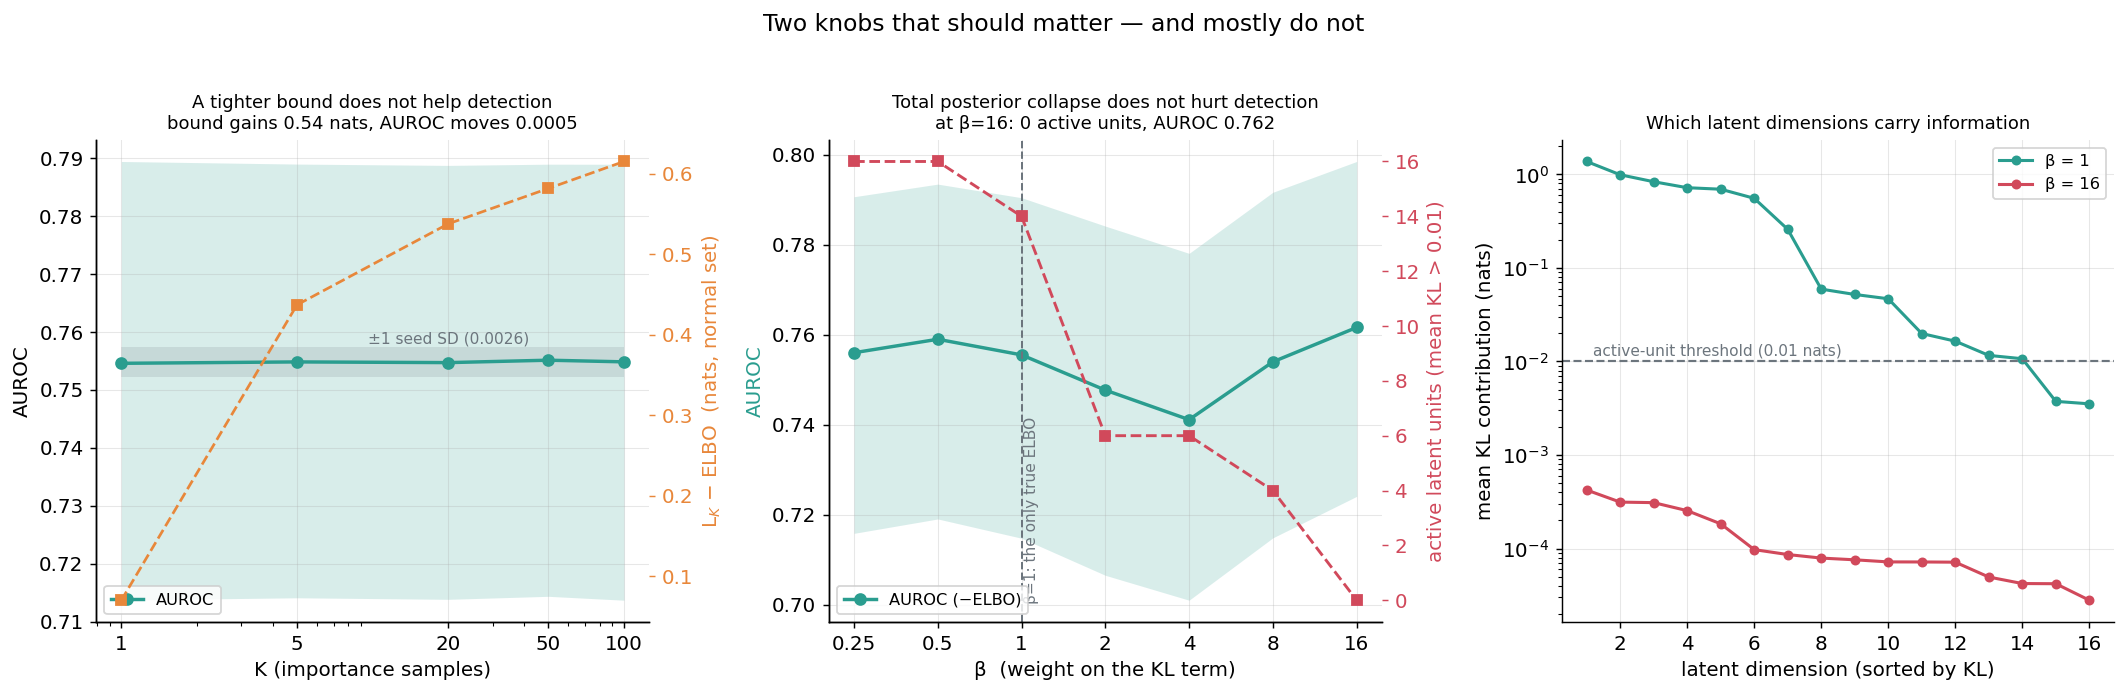

In [14]:
m_hi, _ = T.train(d["train_normal"], d["val_normal"], latent_dim=16,
                  beta=16.0, epochs=300, seed=0)
kl_pd = {"beta1": T.active_units(model, d["train_normal"], dev)["kl_per_dim"],
         "beta_high": T.active_units(m_hi, d["train_normal"], dev)["kl_per_dim"]}
P.bound_and_collapse(iwae, beta, kl_pd, stab, "../figures/06_bound_and_collapse.png")
Image("../figures/06_bound_and_collapse.png")

**latent 單元大量死亡，AUROC 幾乎不跟隨。**

這是本專案最違反直覺的結果。合起來看，前兩節已經解釋了它：
分數的判別力**幾乎完全來自重建項**（第一本 notebook 第 3 節），
而重建項**大部分是複雜度**（本 notebook 第 2 節）。
latent 空間本來就沒在貢獻多少 —— 所以摧毀它也沒差多少。

### 3.3 latent 容量

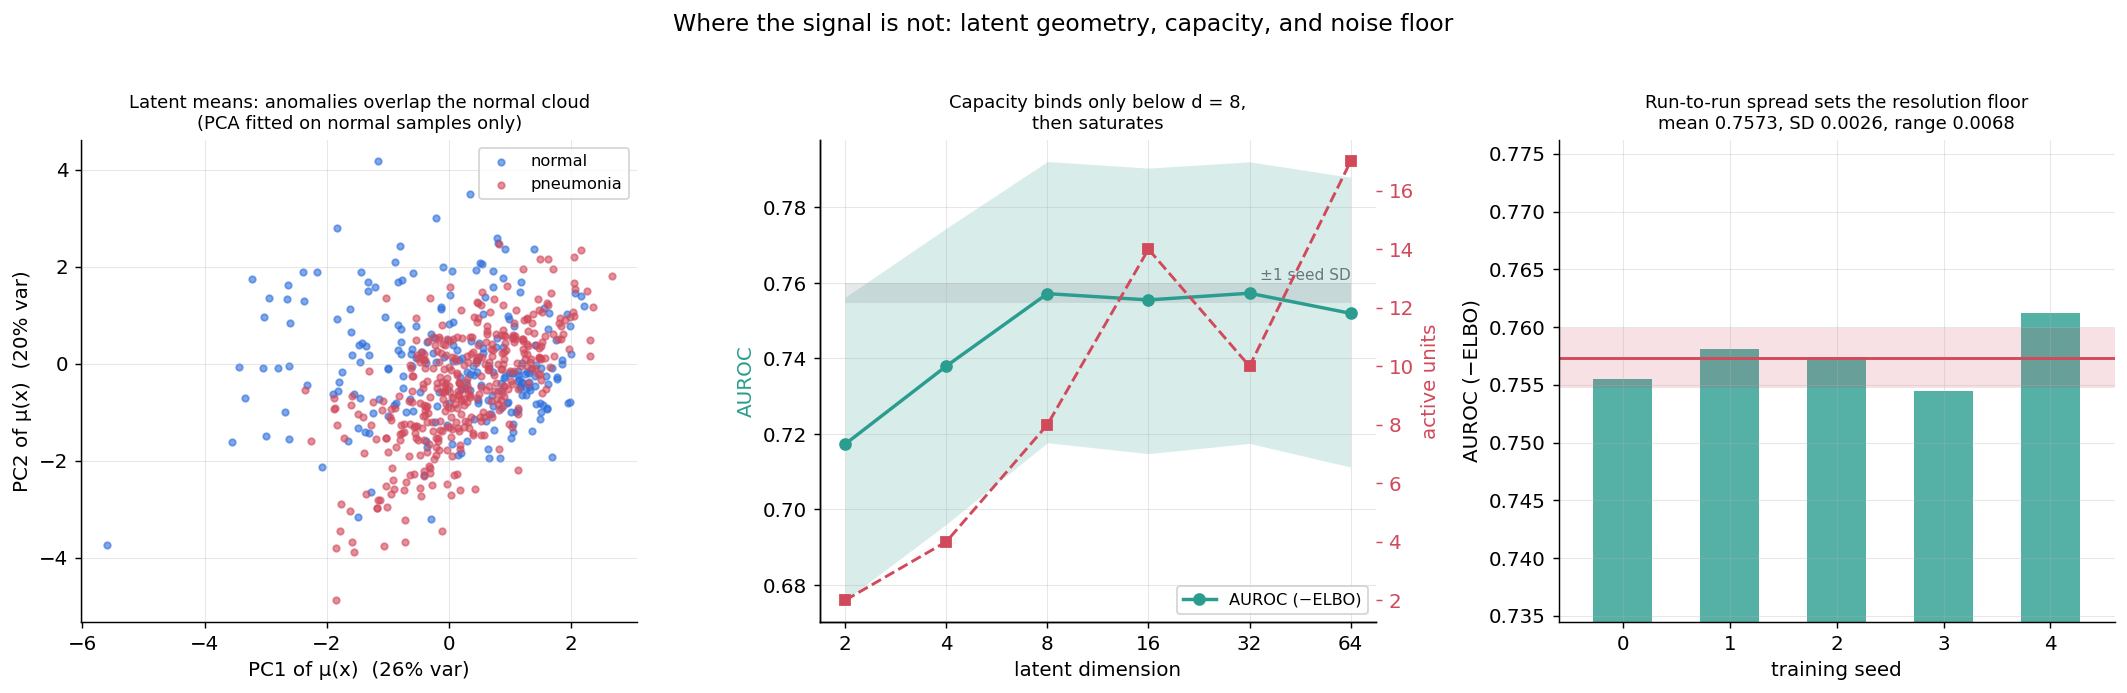

In [15]:
P.latent_capacity_seed(X.latent_embedding(model, {"test_normal": d["test_normal"],
                                                  "test_anomaly": d["test_anomaly"]}, dev),
                       latent, stab, "../figures/07_latent_capacity_seed.png")
Image("../figures/07_latent_capacity_seed.png")

In [16]:
print(f"seed 標準差（噪聲底線）= {stab['sd']:.4f}\n")
for name, rng_ in [("IWAE 的 K (1→100)", max(r['auroc'] for r in iwae['rows']) -
                                          min(r['auroc'] for r in iwae['rows'])),
                   ("β (0.25→16)", max(r['auroc_elbo'] for r in beta['rows']) -
                                    min(r['auroc_elbo'] for r in beta['rows'])),
                   ("latent 維度 (2→64)", max(r['auroc_elbo'] for r in latent['rows']) -
                                          min(r['auroc_elbo'] for r in latent['rows'])),
                   ("複雜度校正", corr['neg_elbo']['paired_delta']['delta'])]:
    print(f"  {name:<22s} 效應 {rng_:+.4f}  = {abs(rng_)/stab['sd']:5.1f} σ")

seed 標準差（噪聲底線）= 0.0026

  IWAE 的 K (1→100)       效應 +0.0005  =   0.2 σ
  β (0.25→16)            效應 +0.0205  =   7.8 σ
  latent 維度 (2→64)       效應 +0.0399  =  15.3 σ
  複雜度校正                  效應 +0.1253  =  47.9 σ


---

## 結論

| 問題 | 答案 |
|---|---|
| VAE 的 ELBO 能偵測肺炎嗎？ | 能，AUROC ≈ 0.76 —— **通關標準成立** |
| 比不看模型的統計好嗎？ | **不好**。gradient energy 0.915，高出 16 個百分點 |
| ELBO 在測什麼？ | 一大半是影像複雜度。控制後淨貢獻只剩約 +0.10 |
| 收緊下界（IWAE）有用嗎？ | **完全沒用**，0.3σ |
| 調 β / latent 維度有用嗎？ | 幾乎沒用；collapse 到 2 個單元 AUROC 也不掉 |
| 什麼**真的**有用？ | 扣掉複雜度：**+0.125**，勝率 100% |

**方法論上的收穫，比 AUROC 數字重要**：

1. **通關標準會說謊**。「異常的 ELBO 明顯較低」是真的，
   而且如果只做到這裡，這會是一個看起來成功的專案。
   加一個兩行的 baseline，結論就翻轉了。

2. **調超參數之前先建噪聲底線**。如果沒先跑 5 個 seed，
   β 掃描那條上升的曲線看起來會很像一個發現。

3. **知道分數在測什麼，比讓分數變高更有價值**。
   複雜度校正之所以有效（+0.125，遠超所有超參數），
   正是因為它針對的是**已經診斷出來的**失效機制，而不是盲調。

### 這和前九個專案的關係

C2 專案發現「固定 β 的 SIR 收斂完美卻得到 86.8% 感染率的荒謬解」——
模型失配偽裝成參數估計。這裡是同一件事的另一個面向：
**指標達標偽裝成方法有效**。兩者都只能靠「在模型之外找一個獨立的檢查」抓出來。

👉 完整敘事與限制見 [README](../README.md)